In [1]:
!pip install -q --upgrade "protobuf<=3.20.1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 4.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.26.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-cloud-translate 3.12.1 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.19.5, but you have protobuf 3.20.1 which is incompatible.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 3.20.1 which is incompatible.
google-cloud-vision 3.11.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.20.2, but you have protobuf 3.20.1 which is incompatible.
onnx 1.20.0 requires protobuf>=4.25.1, but you have protobuf 3.20.1 which is incompatible.
google-cloud-videointelligence 2.17.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5

In [2]:
!pip install -q peft tqdm vmdpy

In [3]:
import numpy as np
import pandas as pd
import os
import scipy.sparse as sp
import pickle
import gc
import math

import torch
import torch.nn as nn
import torch.nn.functional as Fuct
from torch.optim.optimizer import Optimizer

from transformers import GPT2Model
from transformers.modeling_outputs import BaseModelOutputWithPastAndCrossAttentions
from transformers.models.gpt2.modeling_gpt2 import GPT2Attention, GPT2Block

from typing import Optional, Tuple, Union
from peft import LoraConfig, get_peft_model

import time
import random
from tqdm import tqdm

from vmdpy import VMD

# from concurrent.futures import ProcessPoolExecutor
from torch.utils.checkpoint import checkpoint
from concurrent.futures import ProcessPoolExecutor, as_completed

2025-12-30 16:02:56.787534: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767110577.001731      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767110577.067846      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767110577.625478      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767110577.625526      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767110577.625529      24 computation_placer.cc:177] computation placer alr

In [ ]:
# Fix for duplicate library
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [ ]:
# ============================================================================
# 1. UTILITIES & DATA LOADING
# ============================================================================

def load_pickle(pickle_file):
    """Load a pickle file with fallback for different encodings."""

    try:
        with open(pickle_file, 'rb') as f:
            pickle_data = pickle.load(f)
    except UnicodeDecodeError as e:
        with open(pickle_file, 'rb') as f:
            pickle_data = pickle.load(f, encoding='latin1')
    except Exception as e:
        print('Unable to load data ', pickle_file, ':', e)
        raise
    return pickle_data


def decompose_single_window(window_data, K=3, alpha=2000, tau=0, DC=0, init=1, tol=1e-7):
    """
    Decomposes a single sample window [T, N, 1].
    Includes checks for Constant Signals and NaNs.
    """
    T, N, _ = window_data.shape
    modes_out = np.zeros((K, T, N, 1), dtype=np.float32)
    
    for n in range(N):
        signal = window_data[:, n, 0] 
        
        # --- CHECK 1: Constant / Flat Signal ---
        # If signal has 0 variance (flat line), VMD will crash (Divide by Zero).
        if np.std(signal) < 1e-6:
            # Fallback: Treat the flat line as the "Trend" (Mode 1), others 0
            modes_out[0, :, n, 0] = signal
            continue # Skip VMD for this node

        # Mirror Padding
        pad_width = T 
        signal_padded = np.pad(signal, (pad_width, pad_width), mode='symmetric')
        
        try:
            # Run VMD
            u, _, _ = VMD(signal_padded, alpha, tau, K, DC, init, tol)
            
            # --- CHECK 2: NaN Output ---
            # Even with checks, VMD sometimes outputs NaNs. Catch them.
            if np.any(np.isnan(u)):
                raise ValueError("VMD returned NaNs")

            # Crop center
            u_cropped = u[:, pad_width : pad_width + T] 
            modes_out[:, :, n, 0] = u_cropped
            
        except Exception:
            # Fallback for any error or NaN result
            # Assign original signal to first mode, others remain 0
            modes_out[0, :, n, 0] = signal
            
    return modes_out


def precompute_vmd_leakage_free(data_x, vmd_k=3, max_workers=4):
    """
    Applies Sliding Window VMD on the entire dataset.
    Input: data_x [Samples, T, N, F]
    Output: vmd_storage [Samples, K, T, N, 1]
    """
    num_samples = data_x.shape[0]
    T = data_x.shape[1]
    N = data_x.shape[2]
    
    print(f"  > Starting Leakage-Free VMD on {num_samples} windows (Len={T})...")
    print(f"  > Mode: Sample-wise (No Data Leakage)")
    print(f"  > Workers: {max_workers}")
    
    # Pre-allocate memory 
    vmd_storage = np.zeros((num_samples, vmd_k, T, N, 1), dtype=np.float32)
    
    # Use ProcessPoolExecutor to utilize all CPU cores
    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        # Dictionary to map futures to sample indices
        # We pass data_x[i] which is [T, N, F]
        futures = {
            executor.submit(decompose_single_window, data_x[i], K=vmd_k): i 
            for i in range(num_samples)
        }
        
        # Collect results as they finish
        for future in tqdm(as_completed(futures), total=num_samples, desc="VMD Progress"):
            idx = futures[future]
            try:
                result = future.result()
                vmd_storage[idx] = result
            except Exception as e:
                print(f"  [Error] Sample {idx} failed: {e}")
                # Fallback: copy raw flow to first mode
                vmd_storage[idx, 0, :, :, 0] = data_x[idx, :, :, 0]

    return vmd_storage


class OptimizedDataLoader(object):
    """Custom data loader that handles X, Y, and VMD data together with batching."""
    def __init__(self, xs, ys, vmd_x, batch_size, pad_with_last_sample=True):
        self.batch_size = batch_size
        self.current_ind = 0
        if pad_with_last_sample:
            num_padding = (batch_size - (len(xs) % batch_size)) % batch_size
            x_padding = np.repeat(xs[-1:], num_padding, axis=0)
            y_padding = np.repeat(ys[-1:], num_padding, axis=0)
            vmd_padding = np.repeat(vmd_x[-1:], num_padding, axis=0)
            
            xs = np.concatenate([xs, x_padding], axis=0)
            ys = np.concatenate([ys, y_padding], axis=0)
            vmd_x = np.concatenate([vmd_x, vmd_padding], axis=0)
            
        self.size = len(xs)
        self.num_batch = int(self.size // self.batch_size)
        self.xs = xs
        self.ys = ys
        self.vmd_x = vmd_x 

    def shuffle(self):
        permutation = np.random.permutation(self.size)
        self.xs = self.xs[permutation]
        self.ys = self.ys[permutation]
        self.vmd_x = self.vmd_x[permutation]

    def get_iterator(self):
        self.current_ind = 0
        def _wrapper():
            while self.current_ind < self.num_batch:
                start_ind = self.batch_size * self.current_ind
                end_ind = min(self.size, self.batch_size * (self.current_ind + 1))
                
                x_i = self.xs[start_ind:end_ind, ...]
                y_i = self.ys[start_ind:end_ind, ...]
                vmd_i = self.vmd_x[start_ind:end_ind, ...]
                
                yield (x_i, y_i, vmd_i)
                self.current_ind += 1
        return _wrapper()



def load_dataset_optimized(dataset_dir, batch_size, args, force_recompute=False):
    """
    Load and preprocess traffic dataset with VMD decomposition.
    
    - Adds temporal features (time-of-day, day-of-week) if not present
    - Normalizes flow data using StandardScaler
    - Computes or loads cached VMD decomposition
    - Returns train/val/test data loaders
    
    Args:
        dataset_dir: Path to directory containing train.npz, val.npz, test.npz
        batch_size: Batch size for data loaders
        args: Configuration object with data, input_len attributes
        force_recompute: If True, recompute VMD even if cached
    """
    import os
    
    # Cache directories
    input_cache_dir = f"/kaggle/input/vmd-cache-pems04"
    output_cache_dir = "./vmd_cache"
    os.makedirs(output_cache_dir, exist_ok=True)

    data = {}
    cumulative_offset = 0  # FIX: Track chronological position across splits
    
    for category in ["train", "val", "test"]:
        cat_data = np.load(os.path.join(dataset_dir, category + ".npz"))
        x_raw = cat_data["x"]  # [Samples, T, N, F]
        y_raw = cat_data["y"]
        
        # --- PeMS TEMPORAL FEATURE GENERATION ---
        if x_raw.shape[-1] < 3:
            print(f"[{category}] Adding temporal features (offset={cumulative_offset})...")
            
            num_samples, T_len, num_nodes, _ = x_raw.shape
            
            # FIX: Use cumulative offset for correct chronological alignment
            # Each sample i starts at timestep (i + cumulative_offset)
            sample_starts = np.arange(num_samples) + cumulative_offset
            step_indices = sample_starts[:, None] + np.arange(T_len)[None, :]  # [num_samples, T_len]
            
            # 1. Time-of-Day: normalized between 0 and 1 (288 steps/day)
            time_of_day = (step_indices % 288) / 288.0
            time_of_day = time_of_day[:, :, None, None]  # [S, T, 1, 1]
            time_of_day = np.tile(time_of_day, (1, 1, num_nodes, 1))

            # 2. Day-of-Week: integer 0-6
            day_of_week = (step_indices // 288) % 7
            day_of_week = day_of_week[:, :, None, None].astype(np.float32)
            day_of_week = np.tile(day_of_week, (1, 1, num_nodes, 1))

            # Concatenate: [Flow, Time-of-Day, Day-of-Week]
            x_raw = np.concatenate([x_raw[..., 0:1], time_of_day, day_of_week], axis=-1)
            
            # FIX: Update offset for next split
            cumulative_offset += num_samples

        data["x_" + category] = x_raw
        data["y_" + category] = y_raw

    # Scaling (only scale flow, not temporal features)
    scaler = StandardScaler(mean=data["x_train"][..., 0].mean(), std=data["x_train"][..., 0].std())
    for category in ["train", "val", "test"]:
        data["x_" + category][..., 0] = scaler.transform(data["x_" + category][..., 0])
    
    # VMD Caching Helper
    def get_or_compute_vmd(split_name, data_input):
        config_id = f"{args.data}_T{args.input_len}"
        filename = f"vmd_{split_name}_{config_id}.npy"
        
        target_path = os.path.join(output_cache_dir, filename)
        input_path = os.path.join(input_cache_dir, filename)
        
        if os.path.exists(input_path) and not force_recompute:
            print(f"  [External Cache Hit] Loading {split_name} from {input_path}...")
            return np.load(input_path)
        elif os.path.exists(target_path) and not force_recompute:
            print(f"  [Local Cache Hit] Loading {split_name} from {target_path}...")
            return np.load(target_path)
        else:
            print(f"  [Cache Miss] Computing VMD for {split_name}...")
            vmd_result = precompute_vmd_leakage_free(data_input, vmd_k=3, max_workers=4)
            np.save(target_path, vmd_result)
            return vmd_result

    print("Checking VMD Cache for new length...")
    data["vmd_train"] = get_or_compute_vmd("train", data["x_train"])
    data["vmd_val"]   = get_or_compute_vmd("val", data["x_val"])
    data["vmd_test"]  = get_or_compute_vmd("test", data["x_test"])

    # Shuffling
    print("Shuffling Training Data...")
    perm = np.random.permutation(len(data["x_train"]))
    data["x_train"] = data["x_train"][perm]
    data["y_train"] = data["y_train"][perm]
    data["vmd_train"] = data["vmd_train"][perm]

    data["train_loader"] = OptimizedDataLoader(data["x_train"], data["y_train"], data["vmd_train"], batch_size)
    data["val_loader"] = OptimizedDataLoader(data["x_val"], data["y_val"], data["vmd_val"], batch_size)
    data["test_loader"] = OptimizedDataLoader(data["x_test"], data["y_test"], data["vmd_test"], batch_size)
    data["scaler"] = scaler
    return data

class StandardScaler:
    def __init__(self, mean, std):
        self.mean = mean
        self.std = std
    def transform(self, data):
        return (data - self.mean) / self.std
    def inverse_transform(self, data):
        return (data * self.std) + self.mean


# Metrics
def MAE_torch(pred, true, mask_value=None):
    if mask_value != None:
        mask = torch.gt(true, mask_value)
        pred = torch.masked_select(pred, mask)
        true = torch.masked_select(true, mask)
    return torch.mean(torch.abs(true - pred))

def MAPE_torch(pred, true, mask_value=None):
    if mask_value != None:
        mask = torch.gt(true, mask_value)
        pred = torch.masked_select(pred, mask)
        true = torch.masked_select(true, mask)
    return torch.mean(torch.abs(torch.div((true - pred), true)))

def RMSE_torch(pred, true, mask_value=None):
    if mask_value != None:
        mask = torch.gt(true, mask_value)
        pred = torch.masked_select(pred, mask)
        true = torch.masked_select(true, mask)
    return torch.sqrt(torch.mean((pred - true) ** 2))

def WMAPE_torch(pred, true, mask_value=None):
    if mask_value != None:
        mask = torch.gt(true, mask_value)
        pred = torch.masked_select(pred, mask)
        true = torch.masked_select(true, mask)
    loss = torch.sum(torch.abs(pred - true)) / torch.sum(torch.abs(true))
    return loss

def metric(pred, real):
    mae = MAE_torch(pred, real, 0).item()
    mape = MAPE_torch(pred, real,0).item()
    wmape = WMAPE_torch(pred, real, 0).item()
    rmse = RMSE_torch(pred, real, 0).item()
    return mae, mape, rmse, wmape

def metric_per_horizon(pred, real):
    # pred/real shape: [Batch, Horizon, Nodes, 1]
    mae_list, mape_list, rmse_list = [], [], []
    
    for t in range(real.shape[1]):
        p = pred[:, t, ...]
        r = real[:, t, ...]
        mae_list.append(MAE_torch(p, r, 0).item())
        mape_list.append(MAPE_torch(p, r, 0).item())
        rmse_list.append(RMSE_torch(p, r, 0).item())
        
    return mae_list, mape_list, rmse_list

# Ranger Optimizer
class Ranger(Optimizer):
    def __init__(self, params, lr=1e-3, alpha=0.5, k=6, N_sma_threshhold=5, betas=(0.95, 0.999), eps=1e-5, weight_decay=0, use_gc=True, gc_conv_only=False):
        if not 0.0 <= alpha <= 1.0: raise ValueError(f"Invalid slow update rate: {alpha}")
        defaults = dict(lr=lr, alpha=alpha, k=k, step_counter=0, betas=betas, N_sma_threshhold=N_sma_threshhold, eps=eps, weight_decay=weight_decay)
        super().__init__(params, defaults)
        self.N_sma_threshhold = N_sma_threshhold
        self.alpha = alpha
        self.k = k
        self.radam_buffer = [[None, None, None] for ind in range(10)]
        self.use_gc = use_gc
        self.gc_gradient_threshold = 3 if gc_conv_only else 1

    def step(self, closure=None):
        loss = None
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None: continue
                grad = p.grad.data.float()
                if grad.is_sparse: raise RuntimeError("Ranger optimizer does not support sparse gradients")
                p_data_fp32 = p.data.float()
                state = self.state[p]
                if len(state) == 0:
                    state["step"] = 0
                    state["exp_avg"] = torch.zeros_like(p_data_fp32)
                    state["exp_avg_sq"] = torch.zeros_like(p_data_fp32)
                    state["slow_buffer"] = torch.empty_like(p.data)
                    state["slow_buffer"].copy_(p.data)
                else:
                    state["exp_avg"] = state["exp_avg"].type_as(p_data_fp32)
                    state["exp_avg_sq"] = state["exp_avg_sq"].type_as(p_data_fp32)

                exp_avg, exp_avg_sq = state["exp_avg"], state["exp_avg_sq"]
                beta1, beta2 = group["betas"]
                if grad.dim() > self.gc_gradient_threshold:
                    grad.add_(-grad.mean(dim=tuple(range(1, grad.dim())), keepdim=True))
                state["step"] += 1
                exp_avg.mul_(beta1).add_(grad, alpha=1 - beta1)
                exp_avg_sq.mul_(beta2).addcmul_(grad, grad, value=1 - beta2)
                
                buffered = self.radam_buffer[int(state["step"] % 10)]
                if state["step"] == buffered[0]:
                    N_sma, step_size = buffered[1], buffered[2]
                else:
                    buffered[0] = state["step"]
                    beta2_t = beta2 ** state["step"]
                    N_sma_max = 2 / (1 - beta2) - 1
                    N_sma = N_sma_max - 2 * state["step"] * beta2_t / (1 - beta2_t)
                    buffered[1] = N_sma
                    if N_sma > self.N_sma_threshhold:
                        step_size = math.sqrt((1 - beta2_t) * (N_sma - 4) / (N_sma_max - 4) * (N_sma - 2) / N_sma * N_sma_max / (N_sma_max - 2)) / (1 - beta1 ** state["step"])
                    else:
                        step_size = 1.0 / (1 - beta1 ** state["step"])
                    buffered[2] = step_size

                if group["weight_decay"] != 0:
                    p_data_fp32.add_(p_data_fp32, alpha=-group["weight_decay"] * group["lr"])
                if N_sma > self.N_sma_threshhold:
                    denom = exp_avg_sq.sqrt().add_(group["eps"])
                    p_data_fp32.addcdiv_(exp_avg, denom, value=-step_size * group["lr"])
                else:
                    p_data_fp32.add_(exp_avg, alpha=-step_size * group["lr"])
                p.data.copy_(p_data_fp32)
                if state["step"] % group["k"] == 0:
                    slow_p = state["slow_buffer"]
                    slow_p.add_(p.data - slow_p, alpha=self.alpha)
                    p.data.copy_(slow_p)
        return loss

In [ ]:
class TemporalEmbedding(nn.Module):
        """
    Learnable temporal embeddings for time-of-day and day-of-week.
    
    Args:
        time: Number of time slots per day (288 for 5-min, 48 for 30-min)
        features: Embedding dimension
    """
    def __init__(self, time, features):
        super().__init__()
        self.time = time
        self.time_day = nn.Parameter(torch.empty(time, features))
        self.time_week = nn.Parameter(torch.empty(7, features))
        nn.init.xavier_uniform_(self.time_day)
        nn.init.xavier_uniform_(self.time_week)

    def forward(self, x):
        B, T, N, _ = x.shape
        
        # Use LAST timestep's temporal features (correct for prediction)
        day_emb = x[:, -1, :, 1]   # [B, N]
        week_emb = x[:, -1, :, 2]  # [B, N]
        
        # Index with clamping
        day_idx = (day_emb * self.time).long().clamp(0, self.time - 1)
        week_idx = week_emb.long().clamp(0, 6)
        
        time_day_emb = self.time_day[day_idx]    # [B, N, D]
        time_week_emb = self.time_week[week_idx] # [B, N, D]
        
        combined = time_day_emb + time_week_emb
        return combined.transpose(1, 2).unsqueeze(-1)  # [B, D, N, 1]

In [ ]:
# ============================================================================
# 2. GPT-2 BACKBONE WITH GRAPH ATTENTION
# ============================================================================

# ---------------------------
# 1) Custom Attention (pairwise bias)
# ---------------------------
class CustomGPT2Attention(GPT2Attention):
    """
    Extends HF GPT2Attention to accept attn_bias: [B, H, Tq, Tk] (additive; 0 allow, -inf block).
    Keeps standard causal masking; final mask = causal + attn_bias.
    Uses torch.nn.functional.scaled_dot_product_attention.
    """

    def forward(
        self,
        hidden_states: torch.Tensor,
        layer_past: Optional[Tuple[torch.Tensor, torch.Tensor]] = None,
        attention_mask: Optional[torch.Tensor] = None,      # kept for API compatibility (unused here)
        head_mask: Optional[torch.Tensor] = None,
        encoder_hidden_states: Optional[torch.Tensor] = None,
        encoder_attention_mask: Optional[torch.Tensor] = None,
        use_cache: bool = False,
        output_attentions: bool = False,
        attn_bias: Optional[torch.Tensor] = None,           # NEW: [B, H, Tq, Tk] with 0/-inf
    ):
        # Standard QKV projections (GPT-2 packs Q,K,V in c_attn)
        bsz, seq_len, _ = hidden_states.size()

        query, key, value = self.c_attn(hidden_states).split(self.split_size, dim=2)

        def shape(x):
            # [B, T, D] -> [B, H, T, Hd]
            new_x_shape = x.size()[:-1] + (self.num_heads, x.size(-1) // self.num_heads)
            x = x.view(*new_x_shape)
            return x.permute(0, 2, 1, 3)

        def unshape(x):
            # [B, H, T, Hd] -> [B, T, D]
            x = x.permute(0, 2, 1, 3).contiguous()
            new_x_shape = x.size()[:-2] + (x.size(-2) * x.size(-1),)
            return x.view(*new_x_shape)

        query = shape(query)
        key   = shape(key)
        value = shape(value)

        # Past cache handling
        if layer_past is not None:
            past_key, past_value = layer_past
            key   = torch.cat([past_key, key], dim=-2)
            value = torch.cat([past_value, value], dim=-2)
        present = (key, value) if use_cache else None

        Tq = query.size(-2)
        Tk = key.size(-2)
        H  = query.size(1)

        # Build causal mask (additive; -inf on future)
        causal_disallow = torch.triu(
            torch.ones(Tq, Tk, device=hidden_states.device, dtype=torch.bool),
            diagonal=1
        )
        causal_add = torch.zeros((Tq, Tk), device=hidden_states.device, dtype=query.dtype)
        causal_add = causal_add.masked_fill(causal_disallow, float("-inf"))
        causal_add = causal_add.view(1, 1, Tq, Tk).expand(bsz, H, Tq, Tk)

        # Combine with user-provided attn_bias if present (must be additive 0/-inf)
        if attn_bias is not None:
            # Accept [1|B, 1|H, Tq, Tk]
            if attn_bias.dim() != 4 or attn_bias.size(2) != Tq or attn_bias.size(3) != Tk:
                raise ValueError(f"attn_bias must be [B|1, H|1, Tq, Tk]; got {tuple(attn_bias.size())}")
            if attn_bias.size(0) == 1 and bsz > 1:
                attn_bias = attn_bias.expand(bsz, -1, -1, -1)
            if attn_bias.size(1) == 1 and H > 1:
                attn_bias = attn_bias.expand(-1, H, -1, -1)
            additive_mask = causal_add + attn_bias.to(query.dtype)
        else:
            additive_mask = causal_add

        # SDPA (we set is_causal=False because we already applied causality via additive_mask)
        attn_output = F.scaled_dot_product_attention(
            query, key, value,
            attn_mask=additive_mask,
            dropout_p=self.attn_dropout.p if self.training else 0.0,
            is_causal=False
        )

        # [B, H, T, Hd] -> [B, T, D]
        attn_output = unshape(attn_output)
        attn_output = self.c_proj(attn_output)
        attn_output = self.resid_dropout(attn_output)

        outputs = (attn_output, present)
        if output_attentions:
            # Omit returning full attn probs to keep this minimal and version-safe
            outputs += (None,)
        return outputs


# ---------------------------
# 2) Custom Block (threads attn_bias)
# ---------------------------
class CustomGPT2Block(GPT2Block):
    """
    Same as GPT2Block, but passes attn_bias through to attention.
    """

    def forward(
        self,
        hidden_states: torch.FloatTensor,
        layer_past: Optional[Tuple[torch.Tensor, torch.Tensor]] = None,
        attention_mask: Optional[torch.Tensor] = None,      # kept for API compatibility
        head_mask: Optional[torch.Tensor] = None,
        encoder_hidden_states: Optional[torch.Tensor] = None,
        encoder_attention_mask: Optional[torch.Tensor] = None,
        use_cache: bool = False,
        output_attentions: bool = False,
        attn_bias: Optional[torch.Tensor] = None            # NEW
    ):
        residual = hidden_states
        hidden_states = self.ln_1(hidden_states)

        attn_outputs = self.attn(
            hidden_states,
            layer_past=layer_past,
            attention_mask=attention_mask,
            head_mask=head_mask,
            use_cache=use_cache,
            output_attentions=output_attentions,
            attn_bias=attn_bias
        )
        attn_output = attn_outputs[0]
        outputs = attn_outputs[1:]

        hidden_states = residual + attn_output

        residual = hidden_states
        hidden_states = self.ln_2(hidden_states)
        feed_forward_hidden_states = self.mlp(hidden_states)
        hidden_states = residual + feed_forward_hidden_states

        if use_cache:
            outputs = (hidden_states,) + outputs
        else:
            outputs = (hidden_states,) + outputs[1:]
        return outputs


# ---------------------------
# 3) Patcher (swap blocks and attentions in-place)
# ---------------------------
def patch_gpt2_for_pairwise_mask(gpt2_model):
    """
    Safely patch in-place without calling __init__ on GPT-2 internals.
    We keep the same block/attn instances and just swap their classes,
    so we're version-agnostic w.r.t. GPT2Attention/GPT2Block __init__.
    """
    for i, blk in enumerate(gpt2_model.h):
        # 1) Upgrade the attention module to our custom forward
        blk.attn.__class__ = CustomGPT2Attention

        # 2) Upgrade the block to one that threads attn_bias through
        blk.__class__ = CustomGPT2Block


# ---------------------------
# 4) Utility: build pairwise additive bias from adjacency
# ---------------------------
def adjacency_to_pairwise_bias(
    adj: torch.Tensor, B: int, H: int, device: torch.device, dtype: torch.dtype
) -> torch.Tensor:
    """
    adj: [T, T] with 1 (allow) / 0 (block)
    returns additive bias [B, H, T, T] with 0 for allowed, -inf for blocked.
    """
    assert adj.dim() == 2 and adj.size(0) == adj.size(1), "adj must be [T,T]"
    T = adj.size(0)
    add = torch.zeros((T, T), device=device, dtype=dtype)
    add = add.masked_fill(~adj.to(torch.bool), float("-inf"))
    add = add.view(1, 1, T, T).expand(B, H, T, T)
    return add


# ---------------------------
# 5) PFA with Gradient Checkpointing
# ---------------------------
class PFA(nn.Module):
    """
    Pre-trained Foundation Adapter: GPT-2 backbone with LoRA fine-tuning
    and graph-aware attention via pairwise adjacency bias.
    """
    def __init__(
        self, 
        device: str = "cuda:0", 
        gpt_layers: int = 6, 
        U: int = 1, 
        dropout_rate: float = 0.0,
        use_gradient_checkpointing: bool = True  # NEW: Enable/disable checkpointing
    ):
        super(PFA, self).__init__()

        # Load GPT-2 (keep your flags)
        self.gpt2 = GPT2Model.from_pretrained(
            "gpt2",
            attn_implementation="eager",
            output_attentions=True,
            output_hidden_states=True
        )

        # Truncate to first gpt_layers
        self.gpt2.h = self.gpt2.h[:gpt_layers]

        self.U = U
        self.device = device
        self.dropout_rate = dropout_rate
        self.dropout = nn.Dropout(p=self.dropout_rate)
        self.lora_rank = 16
        self.use_gradient_checkpointing = use_gradient_checkpointing

        # ---- Patch BEFORE applying LoRA (safer: PEFT still finds c_attn / c_proj) ----
        patch_gpt2_for_pairwise_mask(self.gpt2)

        # ---- LoRA (keep your target modules unchanged) ----
        self.lora_config = LoraConfig(
            r=self.lora_rank,
            lora_alpha=32,
            lora_dropout=self.dropout_rate,
            target_modules=['q_attn', 'c_attn'],   # kept as you had it
            bias="none"
        )
        self.gpt2 = get_peft_model(self.gpt2, self.lora_config)

        # ---- Freezing policy (kept logic) ----
        for layer_index, layer in enumerate(self.gpt2.h):
            for name, param in layer.named_parameters():
                if layer_index < gpt_layers - self.U:
                    if "ln" in name or "wpe" in name:
                        param.requires_grad = True
                    else:
                        param.requires_grad = False
                else:
                    if "mlp" in name:
                        param.requires_grad = False
                    else:
                        param.requires_grad = True

    def custom_forward(
        self,
        input_ids: Optional[torch.LongTensor] = None,
        past_key_values: Optional[Tuple[Tuple[torch.Tensor]]] = None,
        attention_mask: Optional[torch.FloatTensor] = None,   # kept for API compatibility; not used for graph
        token_type_ids: Optional[torch.LongTensor] = None,
        position_ids: Optional[torch.LongTensor] = None,
        head_mask: Optional[torch.FloatTensor] = None,
        inputs_embeds: Optional[torch.FloatTensor] = None,
        encoder_hidden_states: Optional[torch.Tensor] = None,
        encoder_attention_mask: Optional[torch.FloatTensor] = None,
        use_cache: Optional[bool] = None,
        output_attentions: Optional[bool] = None,
        output_hidden_states: Optional[bool] = None,
        return_dict: Optional[bool] = None,
        adjacency_matrix: Optional[torch.FloatTensor] = None,   # [T,T] with 1/0
    ) -> Union[Tuple, dict]:

        output_attentions = output_attentions if output_attentions is not None else self.gpt2.config.output_attentions
        output_hidden_states = output_hidden_states if output_hidden_states is not None else self.gpt2.config.output_hidden_states
        use_cache = use_cache if use_cache is not None else self.gpt2.config.use_cache
        return_dict = return_dict if return_dict is not None else self.gpt2.config.use_return_dict

        if input_ids is not None and inputs_embeds is not None:
            raise ValueError("Specify either input_ids or inputs_embeds, not both.")
        elif input_ids is not None:
            input_shape = input_ids.size()
            batch_size = input_ids.shape[0]
        elif inputs_embeds is not None:
            input_shape = inputs_embeds.size()[:-1]
            batch_size = inputs_embeds.shape[0]
        else:
            raise ValueError("You must specify input_ids or inputs_embeds.")

        device = input_ids.device if input_ids is not None else inputs_embeds.device

        if past_key_values is None:
            past_length = 0
            past_key_values = tuple([None] * len(self.gpt2.h))
        else:
            past_length = past_key_values[0][0].size(-2)

        if position_ids is None:
            position_ids = torch.arange(
                past_length, input_shape[-1] + past_length, dtype=torch.long, device=device
            ).unsqueeze(0)

        if inputs_embeds is None:
            inputs_embeds = self.gpt2.wte(input_ids)
        position_embeds = self.gpt2.wpe(position_ids)
        hidden_states = inputs_embeds + position_embeds  # [B,T,D]

        all_self_attentions = () if output_attentions else None
        all_hidden_states = () if output_hidden_states else None
        presents = () if use_cache else None

        total_layers = len(self.gpt2.h)
        top_start = total_layers - self.U

        # Precompute pairwise bias if adjacency provided (shared across heads)
        pair_bias = None
        if adjacency_matrix is not None:
            H = self.gpt2.config.n_head
            T = hidden_states.size(1)
            # Expect adj [T,T]; if not, raise
            if adjacency_matrix.dim() != 2 or adjacency_matrix.size(0) != T or adjacency_matrix.size(1) != T:
                raise ValueError(f"adjacency_matrix must be [T,T] matching sequence length {T}")
            pair_bias = adjacency_to_pairwise_bias(
                adj=adjacency_matrix.to(device),
                B=batch_size,
                H=H,
                device=device,
                dtype=hidden_states.dtype
            )  # [B,H,T,T]

        # ---- MAIN LAYER LOOP WITH GRADIENT CHECKPOINTING ----
        for i, (block, layer_past) in enumerate(zip(self.gpt2.h, past_key_values)):
            # Determine if this layer should use graph bias
            use_bias = (i >= top_start and pair_bias is not None)
            
            # Only checkpoint during training AND when cache is disabled
            if self.training and self.use_gradient_checkpointing and not use_cache:
                # Create a wrapper function for checkpointing
                def create_custom_forward(module, current_bias):
                    def custom_forward(hidden_states_input):
                        # Call block with fixed bias
                        outputs = module(
                            hidden_states_input,
                            layer_past=None,  # Can't use cache with checkpointing
                            attention_mask=None,
                            head_mask=head_mask[i] if head_mask is not None else None,
                            use_cache=False,
                            output_attentions=False,  # Simpler for checkpointing
                            attn_bias=current_bias
                        )
                        return outputs[0]  # Return only hidden states
                    return custom_forward
                
                # Apply gradient checkpointing
                hidden_states = checkpoint(
                    create_custom_forward(block, pair_bias if use_bias else None),
                    hidden_states,
                    use_reentrant=False  # use_reentrant=False is recommended for modern PyTorch
                )
                
            else:
                # Standard forward pass (no checkpointing)
                outputs = block(
                    hidden_states,
                    layer_past=layer_past,
                    attention_mask=None,   # we handle masking via attn_bias + internal causal
                    head_mask=head_mask[i] if head_mask is not None else None,
                    use_cache=use_cache,
                    output_attentions=output_attentions,
                    attn_bias=pair_bias if use_bias else None
                )
                hidden_states = outputs[0]

                if use_cache:
                    presents = presents + (outputs[1],)
                if output_attentions:
                    all_self_attentions = all_self_attentions + (outputs[2] if len(outputs) > 2 else None,)

        hidden_states = self.gpt2.ln_f(hidden_states)
        hidden_states = hidden_states.view((-1,) + input_shape[1:] + (hidden_states.size(-1),))

        if not return_dict:
            return tuple(
                v for v in [hidden_states, presents, all_hidden_states, all_self_attentions] if v is not None
            )

        return BaseModelOutputWithPastAndCrossAttentions(
            last_hidden_state=hidden_states,
            past_key_values=presents,
            hidden_states=all_hidden_states,
            attentions=all_self_attentions
        )

    def forward(self, x: torch.Tensor, adjacency_matrix: torch.Tensor):
        """
        x: [B, T, D] - Input embeddings
        adjacency_matrix: [T, T] with 1 (allow) / 0 (block)
        """
        out = self.custom_forward(
            inputs_embeds=x,
            adjacency_matrix=adjacency_matrix,
            use_cache=False  # Important: disable cache when using checkpointing
        ).last_hidden_state
        out = self.dropout(out)
        return out

In [ ]:
class SingleMode_Dynamic_STLLM(nn.Module):
    """
    Spatio-Temporal LLM for a single VMD mode.
    
    Combines:
    - Temporal multi-scale convolutions
    - Dynamic graph learning via GAT
    - GPT-2 backbone with graph attention
    """
    def __init__(
        self, 
        device, 
        adj_mx, 
        input_dim=3, 
        num_nodes=266,      
        input_len=12, 
        output_len=12, 
        llm_layer=6, 
        U=1,   
        # Dynamic Graph Hyperparams
        use_dynamic_graph=True,
        heads=4, 
        tau_hi=0.8, 
        tau_lo=0.5, 
        p_keep=0.15, 
        min_neighbors=20,
        mix_hi=0.6, 
        mix_lo=0.2, 
        k_min=16, 
        k_max=28
    ):
        super().__init__()
        self.device = device
        self.adj_mx = torch.tensor(adj_mx, dtype=torch.float32).to(device)
        self.input_dim = input_dim
        self.num_nodes = num_nodes
        self.output_len = output_len
        self.use_dynamic_graph = use_dynamic_graph
        
        # Params
        self.heads = heads
        self.tau_hi, self.tau_lo = tau_hi, tau_lo
        self.p_keep = p_keep
        self.min_neighbors = int(min_neighbors)
        # self.register_buffer("global_step", torch.zeros((), dtype=torch.long))
        # self.register_buffer("ema_A", torch.empty(0))
        # self.register_buffer("prev_A", torch.empty(0))

        self.register_buffer("global_step", torch.zeros((), dtype=torch.long))
        self.register_buffer("ema_A", torch.zeros((num_nodes, num_nodes)))
        self.register_buffer("prev_A", torch.zeros((num_nodes, num_nodes)))
        
        self.head_dropout = 0.1
        self.leaky_slope = 0.2
        self.gat_tau = 1.0
        self.ema_m = 0.99
        self.eps = 1e-6
        self.edge_dropout = 0.1
        self.symmetrize = True
        self.hysteresis_ratio = 0.8
        self.warmup_steps = 500

        self.k_min, self.k_max = k_min, k_max
        self.mix_hi, self.mix_lo = mix_hi, mix_lo
        # -----------------------------------------

        # Dimensions
        # time_steps = 288 if num_nodes in [170, 207] else 48
        # 48 for NYCTaxi and CHBike
        # =============================================================================================
        time_steps = 288 #PEMS 
        gpt_channel, to_gpt_channel = 256, 768
        
        # Front-end
        self.start_conv = nn.Conv2d(input_dim * input_len, gpt_channel, kernel_size=(1, 1))
        self.Temb = TemporalEmbedding(time_steps, gpt_channel)
        self.node_emb = nn.Parameter(torch.empty(num_nodes, gpt_channel))
        nn.init.xavier_uniform_(self.node_emb)
        
        self.in_layer = nn.Conv2d(gpt_channel * 3, to_gpt_channel, kernel_size=(1, 1))
        self.feat_norm = nn.LayerNorm(to_gpt_channel)
        
        # Graph Learning Parts
        self.gat_q = nn.Linear(to_gpt_channel, to_gpt_channel, bias=False)
        self.gat_k = nn.Linear(to_gpt_channel, to_gpt_channel, bias=False)
        self.gat_a = nn.Parameter(torch.randn(heads, 2 * to_gpt_channel, 1) * (1.0 / math.sqrt(to_gpt_channel)))
        self.bilin_W = nn.Parameter(torch.randn(to_gpt_channel, to_gpt_channel) * (1.0 / math.sqrt(to_gpt_channel)))
        
        # Temporal Multi-scale
        self.tconv1 = nn.Conv1d(input_dim, gpt_channel, 1, padding=0, bias=False)
        self.tconv3 = nn.Conv1d(input_dim, gpt_channel, 3, padding=1, bias=False)
        self.tconv5 = nn.Conv1d(input_dim, gpt_channel, 5, padding=2, bias=False)
        self.tproj  = nn.Linear(3 * gpt_channel, to_gpt_channel, bias=False)
        self.tgate  = nn.Linear(to_gpt_channel, to_gpt_channel)
        
        # Backbone
        self.gpt = PFA(device, gpt_layers=llm_layer, U=U, dropout_rate=0.1)
        self.regression_layer = nn.Conv2d(to_gpt_channel, output_len, kernel_size=(1, 1))


    def _schedule(self):
        t = float(self.global_step.item())
        T = max(self.warmup_steps, 1)
        
        # Linearly interpolate k (for logging/legacy)
        k = int(round(self.k_min + (self.k_max - self.k_min) * min(t / T, 1.0)))
        
        # Linearly interpolate mix (Curriculum: 0.6 -> 0.2)
        mix = self.mix_hi + (self.mix_lo - self.mix_hi) * min(t / T, 1.0)
        
        return k, mix

        

    def _degree_prior(self, A):
        # Returns normalized degree for soft bias
        # A: [S, S]
        degree = A.sum(dim=-1, keepdim=True) # [S, 1]
        max_deg = degree.max() + 1e-6
        return degree / max_deg
    # -----------------------------

    def _to_BTSF(self, x):
        # Ensure [B, T, S, F]
        if x.dim() == 4 and x.shape[1] == self.input_dim: 
            return x.permute(0, 3, 2, 1).contiguous()
        return x

    def _temporal_ms_feats(self, history_data):
        # history_data: [B, T, S, F]
        B, T, S, Fdim = history_data.shape
        x = history_data.permute(0, 2, 3, 1).contiguous().view(B * S, Fdim, T) # [B*S, F, T]
        b1 = F.adaptive_avg_pool1d(F.relu(self.tconv1(x)), 1).squeeze(-1)
        b3 = F.adaptive_avg_pool1d(F.relu(self.tconv3(x)), 1).squeeze(-1)
        b5 = F.adaptive_avg_pool1d(F.relu(self.tconv5(x)), 1).squeeze(-1)
        feats = torch.cat([b1, b3, b5], dim=-1)
        feats = self.tproj(feats).view(B, S, -1)
        return feats

    def _build_adjacency(self, feats) -> torch.Tensor:
        """
        feats: [B, S, D] -> returns binary [S, S] adjacency with
        temperature, EMA smoothing, edge/head dropout, quantile selection,
        degree prior, hysteresis, and warmup union.
        """
        B, S, D = feats.shape
        _, mix_alpha_curr = self._schedule()

        # 1) GAT logits (multi-head) with head-dropout
        h = F.normalize(feats, dim=-1)
        q = self.gat_q(h); k = self.gat_k(h)
        qi = q.unsqueeze(2).expand(-1, -1, S, -1)
        kj = k.unsqueeze(1).expand(-1, S, -1, -1)
        pair = torch.cat([qi, kj], dim=-1)  # [B,S,S,2D]

        logits_per_head = []
        H = self.gat_a.size(0)
        for hidx in range(H):
            if self.training and self.head_dropout > 0 and torch.rand(()) < self.head_dropout:
                continue
            a = self.gat_a[hidx]                              # [2D,1]
            e = torch.matmul(pair, a).squeeze(-1)             # [B,S,S]
            e = F.leaky_relu(e, self.leaky_slope)
            logits_per_head.append(e)
        if len(logits_per_head) == 0:  # fallback if all dropped
            a = self.gat_a[0]
            e = F.leaky_relu(torch.matmul(pair, a).squeeze(-1), self.leaky_slope)
            logits_per_head = [e]

        logits = torch.stack(logits_per_head, dim=1).mean(dim=1)  # [B,S,S]
        logits = logits / max(self.gat_tau, 1e-6)
        A_prob = torch.softmax(logits, dim=-1)                    # [B,S,S]

        # 2) EMA smoothing (batch -> moving average)
        A_mean = A_prob.mean(dim=0).detach()                      # [S,S]
        self.ema_A = self.ema_m * self.ema_A + (1.0 - self.ema_m) * A_mean

        fixed = (self.adj_mx > 0).float()
        fixed = fixed / (fixed.sum(-1, keepdim=True) + self.eps)
        A_blend = (1.0 - mix_alpha_curr) * self.ema_A + mix_alpha_curr * fixed

        # 4) edge dropout (regularize) before selection
        if self.training and self.edge_dropout > 0:
            keep = (torch.rand_like(A_blend) > self.edge_dropout).float()
            A_blend = A_blend * keep

        # 5) degree prior (tiny bias to well-connected nodes)
        prior = self._degree_prior(A_blend)          # [S,1]
        A_blend = A_blend * (0.8 + 0.2 * prior)      # tiny, safe boost

        # 6) ADAPTIVE DENSITY (quantile): keep top p% per row
        A_work = A_blend.clone()
        A_work.fill_diagonal_(0.0)
        # per-row quantile threshold
        p = float(self.p_keep)
        p = min(max(p, 1e-3), 0.99)  # clamp
        thresh = torch.quantile(A_work, 1.0 - p, dim=-1, keepdim=True)  # [S,1]
        A_bin = (A_work >= thresh).float()

        # 7) self-loops; symmetrize
        A_bin.fill_diagonal_(1.0)
        if self.symmetrize:
            A_bin = torch.maximum(A_bin, A_bin.t())

        # 8) HYSTERESIS: keep previous edges unless they are clearly weak now

        row_mean = A_work.mean(dim=-1, keepdim=True)              
        low_mask = (A_work < (row_mean * self.hysteresis_ratio)).float()
        keep_prev = self.prev_A * (1.0 - low_mask)                
        A_bin = torch.clamp(A_bin + keep_prev, 0.0, 1.0)
        self.prev_A = A_bin.detach()

        # 9) warmup: union with fixed graph
        self.global_step += 1
        if self.global_step.item() < self.warmup_steps:
            A_bin = torch.maximum(A_bin, (self.adj_mx > 0).float())

        return A_bin  # [S,S]

    def forward(self, x_in):
        # x_in: [B, T, N, F] (Mode data + Time features)
        x_in = self._to_BTSF(x_in)
        B, T, S, Fdim = x_in.shape
        data = x_in.permute(0, 3, 2, 1) # [B, F, S, T]
        
        # Embeddings
        tem_emb = self.Temb(x_in)
        node_emb = self.node_emb.unsqueeze(0).expand(B, -1, -1).transpose(1, 2).unsqueeze(-1)
        
        input_data = data.transpose(1, 2).contiguous().view(B, S, -1).transpose(1, 2).unsqueeze(-1)
        input_data = self.start_conv(input_data)
        
        data_st = torch.cat([input_data, tem_emb, node_emb], dim=1)
        data_st = self.in_layer(data_st)
        data_st = torch.nn.functional.leaky_relu(data_st).permute(0, 2, 1, 3).squeeze(-1) # [B, S, 768]
        data_st = self.feat_norm(data_st)
        
        # Temporal Guidance
        t_feats = self._temporal_ms_feats(x_in)
        gate = torch.sigmoid(self.tgate(self.feat_norm(t_feats)))
        data_st_fused = data_st + gate * t_feats
        
        # Graph
        if self.use_dynamic_graph:
            adj = self._build_adjacency(data_st_fused)
        else:
            adj = self.adj_mx
            
        # GPT
        out = self.gpt(data_st_fused, adj) # [B, S, 768]
        
        # Project
        out = out.permute(0, 2, 1).unsqueeze(-1)
        pred = self.regression_layer(out) # [B, Out_T, S, 1]
        
        return pred, adj

In [ ]:
# ============================================================================
# 5. INTEGRATED GATLLM 
# ============================================================================
class GATLLM(nn.Module):
    def __init__(self, device, adj_mx, input_dim=3, num_nodes=266, 
                 input_len=12, output_len=12, llm_layer=6, U=1, 
                 vmd_K=3, use_attention_fusion=True):
        super().__init__()
        self.vmd_K = vmd_K
        self.use_attention_fusion = use_attention_fusion
        self.output_len = output_len
        
        # Create a Dynamic Graph ST-LLM for each mode
        # Note: Input dim is usually 3 (Flow, Day, Week)
        # The decomposed input will also have 3 channels (Mode_Flow, Day, Week)
        self.mode_models = nn.ModuleList([
            SingleMode_Dynamic_STLLM(
                device, adj_mx, input_dim, num_nodes, input_len, output_len, 
                llm_layer, U, use_dynamic_graph=True
            ) for _ in range(vmd_K)
        ])
        
        # Fusion Layers
        if use_attention_fusion:
            self.fusion_query = nn.Linear(output_len, output_len)
            self.fusion_key = nn.Linear(output_len, output_len)
            self.fusion_value = nn.Linear(output_len, output_len)
        else:
            self.mode_weights = nn.Parameter(torch.ones(vmd_K) / vmd_K)
            
        # Residual connection from original input (trend preservation)
        self.residual_proj = nn.Sequential(
            nn.Linear(input_len, output_len),
            nn.LayerNorm(output_len),
            nn.ReLU()
        )

    def attention_fusion(self, mode_preds):
        # mode_preds: List of [B, Out_T, N, 1]
        stacked = torch.stack(mode_preds, dim=0) # [K, B, T, N, 1]
        K, B, T, N, _ = stacked.shape
        x = stacked.squeeze(-1).permute(0, 1, 3, 2).reshape(K, B * N, T) # [K, B*N, T]
        
        q = self.fusion_query(x)
        k = self.fusion_key(x)
        v = self.fusion_value(x)
        
        attn = Fuct.softmax(torch.matmul(q, k.transpose(1, 2)) / math.sqrt(T), dim=0)
        # Note: Simple self-attention across modes for the whole sequence
        # We want weights per mode. 
        # Simplified: Calculate attention scores based on content
        scores = torch.mean(torch.matmul(q, k.transpose(1, 2)), dim=-1) # [K, B*N]
        weights = Fuct.softmax(scores, dim=0).unsqueeze(-1).unsqueeze(1).view(K, B, 1, N, 1)
        
        fused = torch.sum(weights * stacked, dim=0)
        return fused

    def forward(self, vmd_data, original_input):
        """
        vmd_data: [B, K, T, N, 1] (Just the flow)
        original_input: [B, T, N, F] (Flow, Day, Week)
        """
        B, K, T, N, _ = vmd_data.shape
        time_feats = original_input[..., 1:] # [B, T, N, 2]
        
        preds = []
        graphs = []
        
        for k in range(K):
            # Construct input for mode k: Concat(Mode_k, Time_Feats)
            mode_flow = vmd_data[:, k, ...] # [B, T, N, 1]
            mode_in = torch.cat([mode_flow, time_feats], dim=-1) # [B, T, N, 3]
            
            p, g = self.mode_models[k](mode_in)
            preds.append(p)
            graphs.append(g)
            
        if self.use_attention_fusion:
            final = self.attention_fusion(preds)
        else:
            w = F.softmax(self.mode_weights, dim=0)
            final = sum(preds[i] * w[i] for i in range(K))
            
        # Residual
        res = original_input[..., 0].permute(0, 2, 1) # [B, N, T]
        res = self.residual_proj(res).permute(0, 2, 1).unsqueeze(-1)
        final = final + 0.1 * res
        
        return final, graphs

    def param_num(self):
        return sum(p.numel() for p in self.parameters())

In [11]:
class VMD_Trainer:
    def __init__(self, args, scaler, adj_mx, device):
        self.args = args
        self.device = device
        self.scaler = scaler
        
        self.model = GATLLM(
            device, adj_mx, args.input_dim, args.num_nodes, 
            args.input_len, args.output_len, args.llm_layer, args.U,
            vmd_K=3
        ).to(device)
        
        self.optimizer = Ranger(self.model.parameters(), lr=args.lrate, weight_decay=args.wdecay)
        self.loss_fn = MAE_torch

    def save_checkpoint(self, epoch, val_loss, path):
        """Saves everything needed to resume training."""
        state = {
            'epoch': epoch,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'best_val_loss': val_loss,
        }
        torch.save(state, path)
        print(f"--- Checkpoint saved to {path} (Epoch {epoch}) ---")

    def load_checkpoint(self, path):
        print(f"--- Loading checkpoint from {path} ---")
        checkpoint = torch.load(path, map_location=self.device, weights_only=False)  # Add weights_only=False
        
        self.model.load_state_dict(checkpoint['model_state_dict'], strict=False)
        
        try:
            self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        except:
            print("Warning: Optimizer state could not be fully loaded. Resetting optimizer.")
            
        return checkpoint['epoch'], checkpoint['best_val_loss']

    
    def train_step(self, x, y_real, vmd_data): 
        self.model.train()
        self.optimizer.zero_grad()
        
        x_in = x.permute(0, 3, 2, 1) 
        
        # Direct usage, no calculation
        preds, _ = self.model(vmd_data, x_in)

        preds = preds.transpose(1, 3)
        preds_scaled = self.scaler.inverse_transform(preds)
        real_scaled = torch.unsqueeze(y_real, 1)
        
        loss = self.loss_fn(preds_scaled, real_scaled, 0.0)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.model.parameters(), 5)
        self.optimizer.step()
        
        return loss.item(), metric(preds_scaled, real_scaled)


    def eval_step(self, x, y_real, vmd_data):
        """
        Fixed eval_step that matches train_step's shape handling.
        Returns aggregated metrics (not per-horizon).
        """
        self.model.eval()
        x_in = x.permute(0, 3, 2, 1)
        
        with torch.no_grad():
            preds, _ = self.model(vmd_data, x_in)
            
        preds = preds.transpose(1, 3)  # [B, 1, N, T]
        preds_scaled = self.scaler.inverse_transform(preds)
        
        # FIX: Use same shape as train_step
        real_scaled = torch.unsqueeze(y_real, 1)  # [B, 1, N, T]
        
        loss = self.loss_fn(preds_scaled, real_scaled, 0.0).item()
        metrics = metric(preds_scaled, real_scaled)  # (mae, mape, rmse, wmape)
        
        return loss, metrics

In [12]:
def test_model(trainer, dataloader, device, model_path):
    """
    Fixed test_model that works with the simplified eval_step.
    Computes per-horizon metrics by slicing predictions.
    """
    print(f"\n>> Loading best model from {model_path} ...")
    trainer.model.load_state_dict(torch.load(model_path, weights_only=False))
    # trainer.model.load_state_dict(torch.load(model_path))
    trainer.model.eval()
    
    # Initialize lists to hold metrics for each of the 12 horizons
    horizon_mae = [[] for _ in range(trainer.args.output_len)]
    horizon_mape = [[] for _ in range(trainer.args.output_len)]
    horizon_rmse = [[] for _ in range(trainer.args.output_len)]
    
    print(">> Starting Detailed Horizon Evaluation...")
    
    for x, y, vmd in tqdm(dataloader["test_loader"].get_iterator(), desc="Testing"):
        tx = torch.Tensor(x).to(device).transpose(1, 3)
        ty = torch.Tensor(y).to(device).transpose(1, 3)[:, 0, :, :]  # [B, N, T]
        tvmd = torch.Tensor(vmd).to(device)
        
        # Get predictions
        x_in = tx.permute(0, 3, 2, 1)
        with torch.no_grad():
            preds, _ = trainer.model(tvmd, x_in)
        
        # preds: [B, Out_T, N, 1]
        preds_scaled = trainer.scaler.inverse_transform(preds)
        
        # ty is [B, N, T], convert to [B, T, N, 1]
        real_scaled = ty.permute(0, 2, 1).unsqueeze(-1)  # [B, T, N, 1]
        
        # Calculate metrics for each horizon
        for t in range(trainer.args.output_len):
            p = preds_scaled[:, t, ...]  # [B, N, 1]
            r = real_scaled[:, t, ...]   # [B, N, 1]
            
            horizon_mae[t].append(MAE_torch(p, r, 0).item())
            horizon_mape[t].append(MAPE_torch(p, r, 0).item())
            horizon_rmse[t].append(RMSE_torch(p, r, 0).item())

    print("\n" + "="*50)
    print(f"{'Horizon':<10} | {'MAE':<10} | {'MAPE':<10} | {'RMSE':<10}")
    print("-" * 50)
    
    total_mae, total_mape, total_rmse = [], [], []
    
    for i in range(trainer.args.output_len):
        m_mae = np.mean(horizon_mae[i])
        m_mape = np.mean(horizon_mape[i])
        m_rmse = np.mean(horizon_rmse[i])
        
        total_mae.append(m_mae)
        total_mape.append(m_mape)
        total_rmse.append(m_rmse)
        
        print(f"Step {i+1:02d}    | {m_mae:<10.4f} | {m_mape:<10.4f} | {m_rmse:<10.4f}")
    
    print("-" * 50)
    print(f"AVERAGE    | {np.mean(total_mae):<10.4f} | {np.mean(total_mape):<10.4f} | {np.mean(total_rmse):<10.4f}")
    print("="*50)

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import numpy as np

def visualize_model_predictions(trainer, dataloader, args, node_idx=0, sample_idx=0):
    """
    Robust visualization with Shape Checking and Inverse Scaling.
    """
    device = args.device
    trainer.model.eval()
    
    # 1. Fetch Data
    iterator = dataloader["test_loader"].get_iterator()
    x, y, vmd = next(iterator)
    
    # 2. Robust Data Preparation
    # VMD: Expected [B, K, T, N, 1]
    tvmd = torch.Tensor(vmd).to(device)
    
    # Input: Expected [B, T, N, F]
    tx = torch.Tensor(x).to(device)
    
    print(f"Debug Shapes -> Input: {tx.shape}, VMD: {tvmd.shape}")
    
    # Auto-Fix Transpose if needed
    if tx.shape[1] == 3 and tx.shape[-1] == 12:
        print(">> Auto-correcting Input shape (Transposing)...")
        tx = tx.permute(0, 3, 2, 1)
        
    # 3. Run Inference
    with torch.no_grad():
        final_pred, graphs = trainer.model(tvmd, tx)

    # 4. Extract & Scale Data
    # A. Input History
    hist_raw = tx[sample_idx, :, node_idx, 0].cpu().numpy()
    
    # B. Ground Truth
    gt_raw = y[sample_idx, :, node_idx, 0] # Shape depends on loader, usually [12]
    
    # C. Prediction
    pred_raw = final_pred[sample_idx, :, node_idx, 0].cpu().numpy()
    
    # --- INTELLIGENT SCALING FIX ---
    if np.mean(np.abs(gt_raw)) > 5:
        print(">> Ground Truth appears to be RAW counts. Transforming Prediction only.")
        gt_real = gt_raw
        hist_real = trainer.scaler.inverse_transform(hist_raw.reshape(-1, 1)).flatten()
        pred_real = trainer.scaler.inverse_transform(pred_raw.reshape(-1, 1)).flatten()
    else:
        print(">> Data appears standardized. Inverse transforming ALL.")
        gt_real = trainer.scaler.inverse_transform(gt_raw.reshape(-1, 1)).flatten()
        hist_real = trainer.scaler.inverse_transform(hist_raw.reshape(-1, 1)).flatten()
        pred_real = trainer.scaler.inverse_transform(pred_raw.reshape(-1, 1)).flatten()

    # 5. Plotting
    fig = plt.figure(figsize=(16, 10))
    plt.suptitle(f"Traffic Forecast Analysis: Node {node_idx}", fontsize=16)
    
    # --- PLOT 1: VMD MODES (Input Decomposition) ---
    ax1 = plt.subplot(2, 2, 1)
    modes = tvmd[sample_idx, :, :, node_idx, 0].cpu().numpy()
    labels = ['Mode 1 (Trend)', 'Mode 2 (Period)', 'Mode 3 (Noise)']
    for k in range(len(modes)):
        ax1.plot(modes[k], label=labels[k] if k < 3 else f"Mode {k}", linestyle='--')
    ax1.set_title("1. Input Decomposition (The 'Ingredients')")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # --- PLOT 2: HISTORY -> FORECAST (The Main Result) ---
    ax2 = plt.subplot(2, 2, 2)
    
    # Create time axis
    T_in = len(hist_real)
    T_out = len(pred_real)
    t_hist = range(0, T_in)
    t_fut = range(T_in, T_in + T_out)
    
    # Plot History
    ax2.plot(t_hist, hist_real, 'k-o', alpha=0.4, label="History (Past)")
    
    # Plot Ground Truth (Future)
    ax2.plot(t_fut, gt_real, 'k--', linewidth=2, label="Ground Truth (Future)")
    
    # Plot Prediction (Future) - Connect to last history point
    connect_x = [T_in - 1, T_in]
    connect_y = [hist_real[-1], pred_real[0]]
    ax2.plot(connect_x, connect_y, 'r-', alpha=0.5) # Visual bridge
    ax2.plot(t_fut, pred_real, 'r-o', linewidth=2, label="Model Forecast")
    
    ax2.axvline(x=T_in - 0.5, color='gray', linestyle=':', alpha=0.5)
    ax2.set_title("2. Traffic Prediction (History + Forecast)")
    ax2.set_xlabel("Time Steps")
    ax2.set_ylabel("Traffic Volume")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # --- PLOT 3: LEARNED GRAPHS (Spatial) ---
    # Crop to first 30 nodes for visibility
    crop = 30
    for k in range(min(3, len(graphs))):
        ax = plt.subplot(2, 4, 5+k) 
        
        # FIX: Check dimensions before slicing
        adj_full = graphs[k].cpu().numpy()
        
        if adj_full.ndim == 3:
            # [Batch, Nodes, Nodes] -> Select sample
            adj = adj_full[sample_idx, :crop, :crop]
        else:
            # [Nodes, Nodes] -> Just crop
            adj = adj_full[:crop, :crop]
        
        sns.heatmap(adj, cmap="Blues", cbar=False, ax=ax, square=True)
        ax.set_title(f"Graph: {labels[k]}")
        ax.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# EXECUTE
# visualize_model_predictions(trainer, dataloader, args, node_idx=100, sample_idx=0)

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import numpy as np

def visualize_advanced_diagnostics(trainer, dataloader, args, node_idx=0, subset_size=40):
    """
    Advanced diagnostics: VMD Reconstruction, Graph Dynamicity, and Attention Logic.
    Fixed to handle tensor shapes correctly.
    """
    device = args.device
    trainer.model.eval()
    
    # 1. Fetch Batch
    iterator = dataloader["test_loader"].get_iterator()
    x, y, vmd = next(iterator)
    
    # 2. Robust Data Preparation
    tvmd = torch.Tensor(vmd).to(device)      # [B, K, T, N, 1]
    tx = torch.Tensor(x).to(device)          # [B, T, N, F]
    
    # FIX: Auto-correct Input shape if it was accidentally transposed upstream
    # We expect [Batch, 12, 266, 3]. If we see [Batch, 3, 266, 12], we flip it.
    if tx.shape[1] == 3 and tx.shape[-1] == 12:
        print(">> Auto-correcting Input shape in Diagnostics...")
        tx = tx.permute(0, 3, 2, 1)

    # 3. VMD RECONSTRUCTION CHECK
    # We verify if Sum(Modes) matches the original signal (sanity check)
    # Original: x[0, :, node, 0]
    original_signal = tx[0, :, node_idx, 0].cpu().numpy()
    
    # Reconstructed: Sum(vmd[0, :, :, node, 0]) over K
    reconstructed_signal = tvmd[0, :, :, node_idx, 0].sum(dim=0).cpu().numpy()
    
    # Scaling check for plotting
    if np.max(np.abs(original_signal)) < 5: # If scaled
        original_signal = trainer.scaler.inverse_transform(original_signal.reshape(-1,1)).flatten()
        reconstructed_signal = trainer.scaler.inverse_transform(reconstructed_signal.reshape(-1,1)).flatten()

    plt.figure(figsize=(10, 4))
    plt.plot(original_signal, 'k-', linewidth=3, alpha=0.3, label="Original Signal")
    plt.plot(reconstructed_signal, 'r--', linewidth=1, label="VMD Reconstruction (Sum)")
    plt.title(f"1. VMD Reconstruction Check (Node {node_idx})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # 4. RUN INFERENCE FOR GRAPH VIZ
    with torch.no_grad():
        _, graphs_batch1 = trainer.model(tvmd, tx)
        
    # Fetch second batch for dynamicity check
    x2, y2, vmd2 = next(iterator)
    tx2 = torch.Tensor(x2).to(device)
    if tx2.shape[1] == 3 and tx2.shape[-1] == 12: tx2 = tx2.permute(0, 3, 2, 1)
    tvmd2 = torch.Tensor(vmd2).to(device)
    
    with torch.no_grad():
        _, graphs_batch2 = trainer.model(tvmd2, tx2)


    # 6. ATTENTION MASK LOGIC
    plt.figure(figsize=(18, 5))
    plt.suptitle("3. Attention Mask Logic (Spatial GPT)", fontsize=16)
    
    # A. Causal Mask
    causal_mask = np.tril(np.ones((subset_size, subset_size)))
    plt.subplot(1, 3, 1)
    sns.heatmap(causal_mask, cmap="Greys", cbar=False, square=True, linewidths=0.5, linecolor='gray')
    plt.title("A. GPT Causal Mask")
    
    # B. Graph Mask (Trend)
    graph_mask = graphs_batch1[0].cpu().numpy()
    if graph_mask.ndim == 3: graph_mask = graph_mask[0]
    graph_mask = graph_mask[:subset_size, :subset_size]
    
    plt.subplot(1, 3, 2)
    sns.heatmap(graph_mask, cmap="Blues", cbar=False, square=True)
    plt.title("B. Learned Graph Mask")
    
    # C. Final Effective Mask (Intersection)
    combined_mask = causal_mask * graph_mask
    plt.subplot(1, 3, 3)
    sns.heatmap(combined_mask, cmap="Greens", cbar=False, square=True)
    plt.title("C. Final Attention Mask (Combined)")
    
    plt.tight_layout()
    plt.show()


# visualize_advanced_diagnostics(trainer, dataloader, args, node_idx=50)

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def visualize_weekly_horizon1(trainer, dataloader, args, node_idx=0, num_steps=2016, start_day='Monday'):
    """
    Adapted for PeMS datasets: 5-minute resolution (288 steps/day).
    """
    print(f"\n>> Collecting PeMS weekly data for Node {node_idx}...")
    trainer.model.eval()
    device = args.device
    
    preds_all, gts_all = [], []
    iterator = dataloader["test_loader"].get_iterator()
    
    count = 0
    with torch.no_grad():
        for x, y, vmd in iterator:
            tx = torch.Tensor(x).to(device)
            tvmd = torch.Tensor(vmd).to(device)
            
            # Standard shape fix for the model pipeline
            if tx.shape[1] == 3 and tx.shape[-1] == 12:
                tx = tx.permute(0, 3, 2, 1)
            
            # Model inference
            preds, _ = trainer.model(tvmd, tx)
            
            # Extract Horizon-1 (Step 0) for target node
            batch_preds = preds[:, 0, node_idx, 0].cpu().numpy()
            batch_gts = y[:, 0, node_idx, 0] 
            
            if torch.is_tensor(batch_gts):
                batch_gts = batch_gts.cpu().numpy()
            
            preds_all.append(batch_preds)
            gts_all.append(batch_gts)
            
            count += len(batch_preds)
            if count >= num_steps:
                break
                
    preds_all = np.concatenate(preds_all)[:num_steps]
    gts_all = np.concatenate(gts_all)[:num_steps]
    
    # Inverse Scaling logic (PeMS is typically standardized)
    pred_real = trainer.scaler.inverse_transform(preds_all.reshape(-1, 1)).flatten()
    if np.max(np.abs(gts_all)) < 10: 
        gt_real = trainer.scaler.inverse_transform(gts_all.reshape(-1, 1)).flatten()
    else:
        gt_real = gts_all
        
    # --- PeMS SPECIFIC PLOTTING ---
    plt.figure(figsize=(25, 8)) # Wider figure for 2016 points
    plt.plot(gt_real, label='Actual Flow', color='#1f77b4', alpha=0.5, linewidth=1.5)
    plt.plot(pred_real, label='PeMS Prediction', color='#d62728', linestyle='--', alpha=0.8, linewidth=1)
    
    day_names = [ 'Day 1', 'Day 2', 'Day 3', 'Day 4', 'Day 5', 'Day 6', 'Day 7']
    s_idx = day_names.index(start_day) if start_day in day_names else 0
    ordered_days = day_names[s_idx:] + day_names[:s_idx]

    # Change: 288 steps per day for PeMS
    steps_per_day = 288 
    tick_pos = np.arange(0, num_steps, steps_per_day)
    tick_labels = [ordered_days[i % 7] for i in range(len(tick_pos))]
    
    plt.xticks(tick_pos, tick_labels)
    for pos in tick_pos:
        plt.axvline(x=pos, color='gray', linestyle=':', alpha=0.3)
    
    plt.title(f"Weekly Traffic Forecast", fontsize=16)
    plt.xlabel("Timeline (5-minute resolution)", fontsize=12)
    plt.ylabel("Traffic Flow", fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, axis='y', linestyle=':', alpha=0.3)
    plt.tight_layout()
    plt.show()

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def visualize_daily_horizon1_pems(trainer, dataloader, args, node_idx=0):
    """
    Plots a 1-day timeline (288 steps) for PeMS data.
    Labels x-axis every 3 hours (0:00, 3:00, ..., 24:00).
    """
    num_steps = 288 # 1 day at 5-minute resolution
    print(f"\n>> Collecting 1-Day PeMS data for Node {node_idx}...")
    
    trainer.model.eval()
    device = args.device
    preds_all, gts_all = [], []
    
    # Use the test_loader iterator (sequential windows)
    iterator = dataloader["test_loader"].get_iterator()
    
    count = 0
    with torch.no_grad():
        for x, y, vmd in iterator:
            tx = torch.Tensor(x).to(device)
            tvmd = torch.Tensor(vmd).to(device)
            
            # Shape correction for the model pipeline
            if tx.shape[1] == 3 and tx.shape[-1] == 12:
                tx = tx.permute(0, 3, 2, 1)
            
            # Inference
            preds, _ = trainer.model(tvmd, tx)
            
            # Extract Horizon-1 (Step 0) for prediction and actual flow
            batch_preds = preds[:, 0, node_idx, 0].cpu().numpy()
            batch_gts = y[:, 0, node_idx, 0] 
            
            if torch.is_tensor(batch_gts):
                batch_gts = batch_gts.cpu().numpy()
            
            preds_all.append(batch_preds)
            gts_all.append(batch_gts)
            
            count += len(batch_preds)
            if count >= num_steps:
                break
                
    # Concatenate and trim to exactly 288 steps
    preds_all = np.concatenate(preds_all)[:num_steps]
    gts_all = np.concatenate(gts_all)[:num_steps]
    
    # Inverse Scaling logic
    pred_real = trainer.scaler.inverse_transform(preds_all.reshape(-1, 1)).flatten()
    if np.mean(np.abs(gts_all)) > 5:
        gt_real = gts_all
    else:
        gt_real = trainer.scaler.inverse_transform(gts_all.reshape(-1, 1)).flatten()
        
    # --- DAILY PLOTTING ---
    plt.figure(figsize=(15, 6))
    plt.plot(gt_real, label='Actual Ground Truth', color='#1f77b4', alpha=0.7, linewidth=2)
    plt.plot(pred_real, label='Model Forecast', color='#d62728', linestyle='--', alpha=0.9, linewidth=1.5)
    
    # Time Labels: 0:00, 3:00, ..., 24:00
    # At 5-min intervals: 1 hour = 12 steps, 3 hours = 36 steps
    tick_positions = np.arange(0, 289, 36)
    tick_labels = [f"{h}:00" for h in range(0, 25, 3)]
    
    plt.xticks(tick_positions, tick_labels)
    
    # Visual grid and vertical separators every 3 hours
    for pos in tick_positions:
        plt.axvline(x=pos, color='gray', linestyle=':', alpha=0.2)
        
    plt.title(f"Daily Traffic Forecast (24 Hours)", fontsize=14)
    plt.xlabel("Time of Day", fontsize=12)
    plt.ylabel("Traffic Flow", fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, axis='y', linestyle=':', alpha=0.4)
    
    plt.tight_layout()
    plt.show()

In [17]:
# ============================================================================
# VERIFICATION CODE - Run this after loading data to verify fixes
# ============================================================================
def verify_temporal_features(data):
    """Run this after load_dataset_optimized to verify temporal features are correct."""
    print("\n" + "="*60)
    print("TEMPORAL FEATURE VERIFICATION")
    print("="*60)
    
    for split in ["train", "val", "test"]:
        x = data[f"x_{split}"]
        print(f"\n{split.upper()} split:")
        print(f"  Shape: {x.shape}")
        print(f"  First sample, first step - ToD: {x[0, 0, 0, 1]:.4f}, DoW: {x[0, 0, 0, 2]:.0f}")
        print(f"  First sample, last step  - ToD: {x[0, -1, 0, 1]:.4f}, DoW: {x[0, -1, 0, 2]:.0f}")
        print(f"  Last sample, first step  - ToD: {x[-1, 0, 0, 1]:.4f}, DoW: {x[-1, 0, 0, 2]:.0f}")
    
    # Check continuity between splits
    train_last_tod = data["x_train"][-1, -1, 0, 1]
    val_first_tod = data["x_val"][0, 0, 0, 1]
    print(f"\nContinuity check:")
    print(f"  Train last ToD: {train_last_tod:.4f}")
    print(f"  Val first ToD:  {val_first_tod:.4f}")
    expected_val_tod = ((12483 % 288) / 288.0)
    print(f"  Expected Val ToD (offset 12483): {expected_val_tod:.4f}")
    
    if abs(val_first_tod - expected_val_tod) < 0.01:
        print("  ✓ Temporal features are correctly aligned!")
    else:
        print("  ✗ WARNING: Temporal features may still be misaligned!")
    print("="*60)


Detected list format from pickle. Extracting matrix...
Adjacency matrix successfully loaded with shape: (307, 307)
[train] Adding temporal features (offset=0)...
[val] Adding temporal features (offset=11878)...
[test] Adding temporal features (offset=13575)...
Checking VMD Cache for new length...
  [External Cache Hit] Loading train from /kaggle/input/vmd-cache-pems04/vmd_train_pems04_T12.npy...
  [External Cache Hit] Loading val from /kaggle/input/vmd-cache-pems04/vmd_val_pems04_T12.npy...
  [External Cache Hit] Loading test from /kaggle/input/vmd-cache-pems04/vmd_test_pems04_T12.npy...
Shuffling Training Data...


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2174: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


Found existing best_model.pth at /kaggle/input/pems04-checkpoint/best_model.pth
Copied best_model.pth to ./logs/best_model.pth
--- Loading checkpoint from /kaggle/input/pems04-checkpoint/latest_checkpoint.pth ---
Resuming from Epoch 53. Previous Best Loss: 18.3940
Start Training...


...


Epoch 59 Results (2315.1s):
TRAIN -> Loss: 17.1442 | MAE: 17.1442 | MAPE: 0.1354 | RMSE: 27.7798
VALID -> Loss: 18.3656 | MAE: 18.3656 | MAPE: 0.1224 | RMSE: 28.4005
>>> Saved Best Model (New Best Val Loss: 18.3656)
--- Checkpoint saved to ./logs/latest_checkpoint.pth (Epoch 59) ---


Epoch 60 Train: 1485it [36:07,  1.46s/it]
Epoch 60 Val: 213it [02:36,  1.36it/s]



Epoch 60 Results (2325.2s):
TRAIN -> Loss: 17.1452 | MAE: 17.1452 | MAPE: 0.1354 | RMSE: 27.7615
VALID -> Loss: 18.3353 | MAE: 18.3353 | MAPE: 0.1242 | RMSE: 28.2928
>>> Saved Best Model (New Best Val Loss: 18.3353)
--- Checkpoint saved to ./logs/latest_checkpoint.pth (Epoch 60) ---

>> Loading best model from ./logs/best_model.pth ...
>> Starting Detailed Horizon Evaluation...


Testing: 425it [05:08,  1.38it/s]



Horizon    | MAE        | MAPE       | RMSE      
--------------------------------------------------
Step 01    | 17.3459    | 0.1297     | 26.0317   
Step 02    | 17.6084    | 0.1291     | 26.6164   
Step 03    | 18.0150    | 0.1318     | 27.2190   
Step 04    | 18.1812    | 0.1241     | 27.6415   
Step 05    | 18.2364    | 0.1236     | 27.7927   
Step 06    | 18.5458    | 0.1288     | 28.3477   
Step 07    | 18.7227    | 0.1308     | 28.6578   
Step 08    | 18.8470    | 0.1286     | 28.8535   
Step 09    | 19.1483    | 0.1323     | 29.2953   
Step 10    | 19.3487    | 0.1319     | 29.6174   
Step 11    | 19.3716    | 0.1357     | 29.6799   
Step 12    | 19.6229    | 0.1338     | 30.0263   
--------------------------------------------------
AVERAGE    | 18.5828    | 0.1300     | 28.3149   

Generating Post-Training Visualizations...
Debug Shapes -> Input: torch.Size([8, 12, 307, 3]), VMD: torch.Size([8, 3, 12, 307, 1])
>> Ground Truth appears to be RAW counts. Transforming Prediction

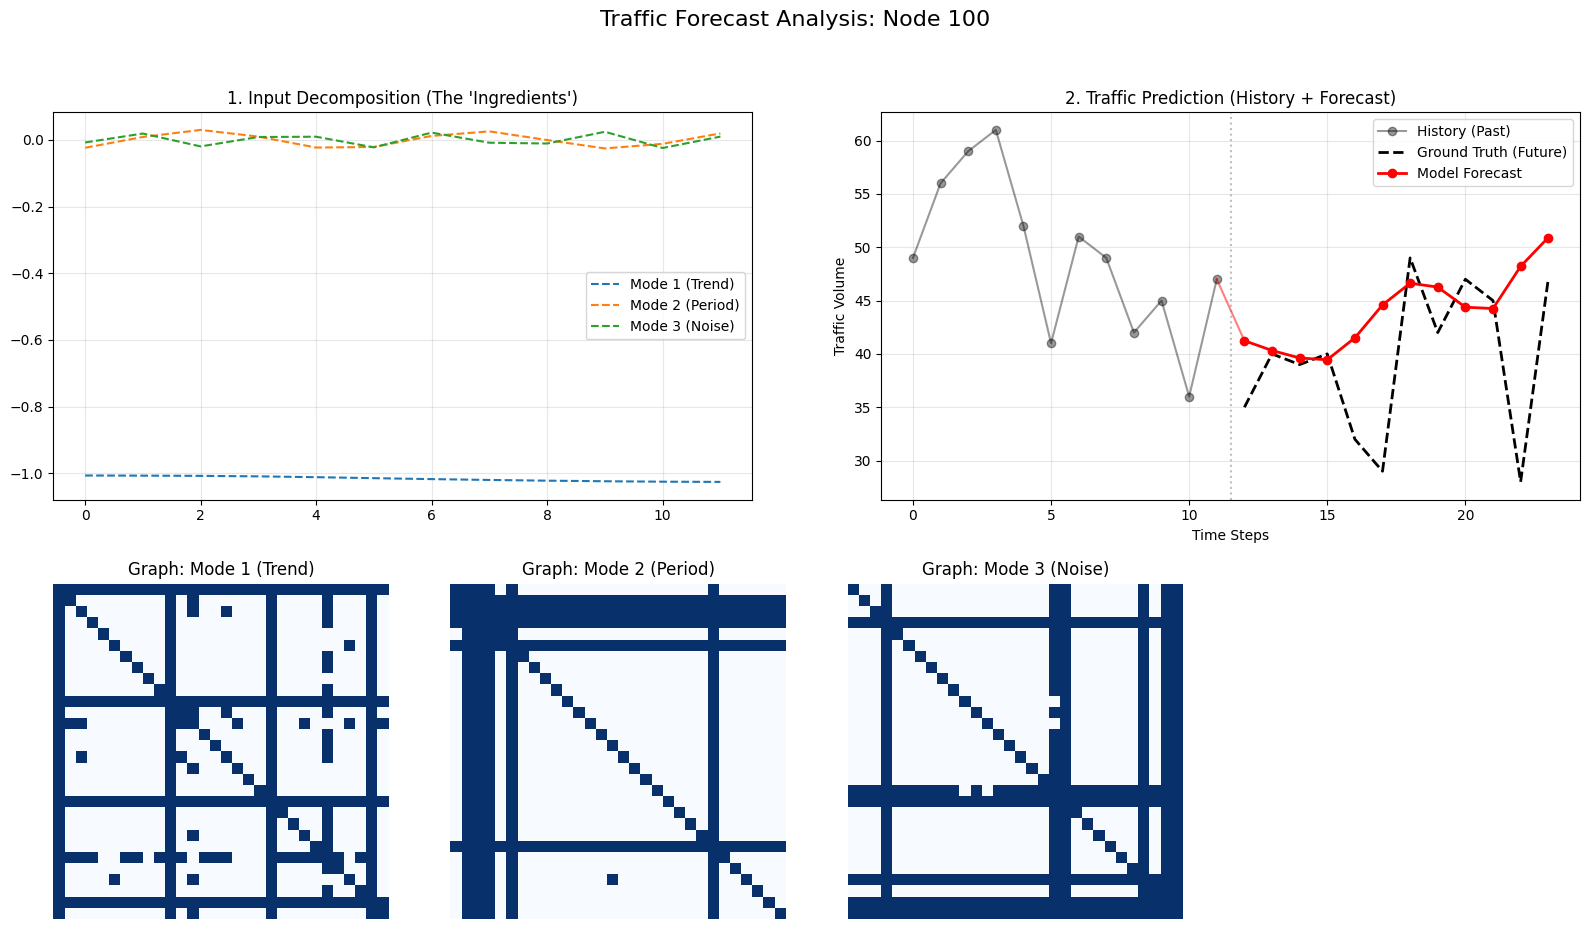

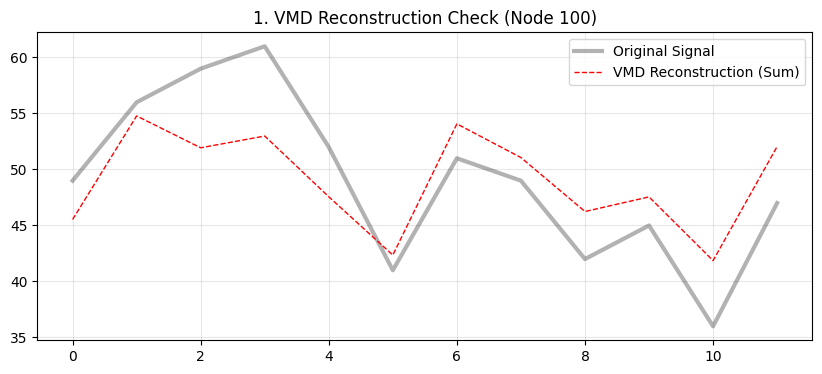

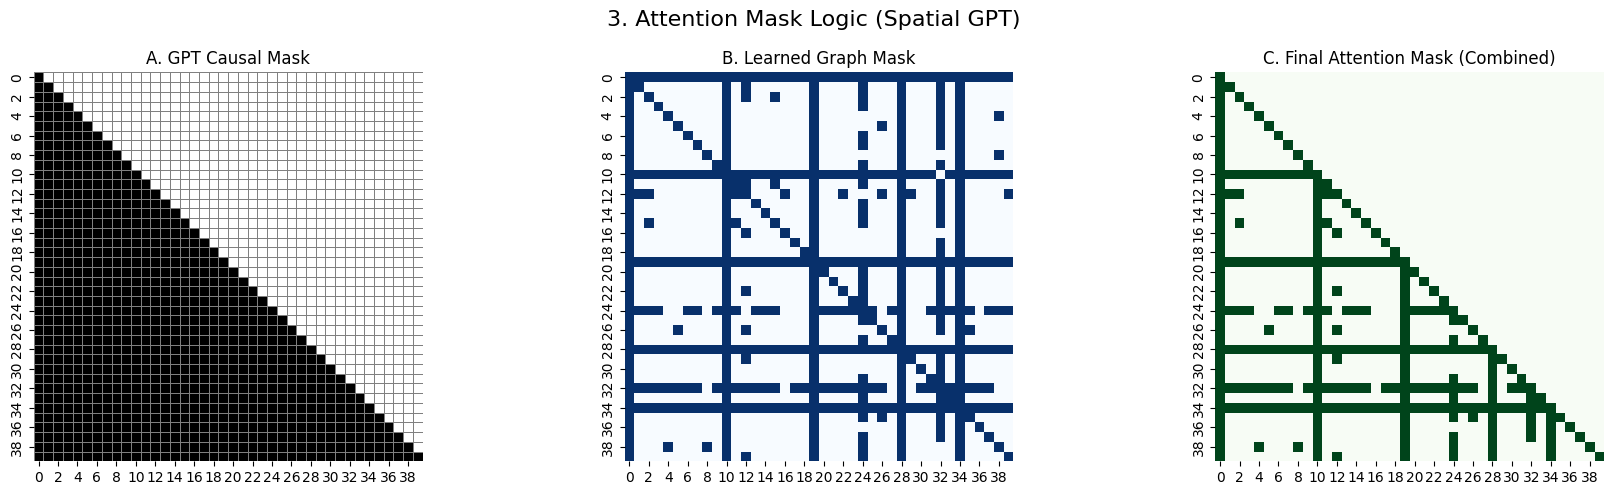


>> Collecting PeMS weekly data for Node 100...


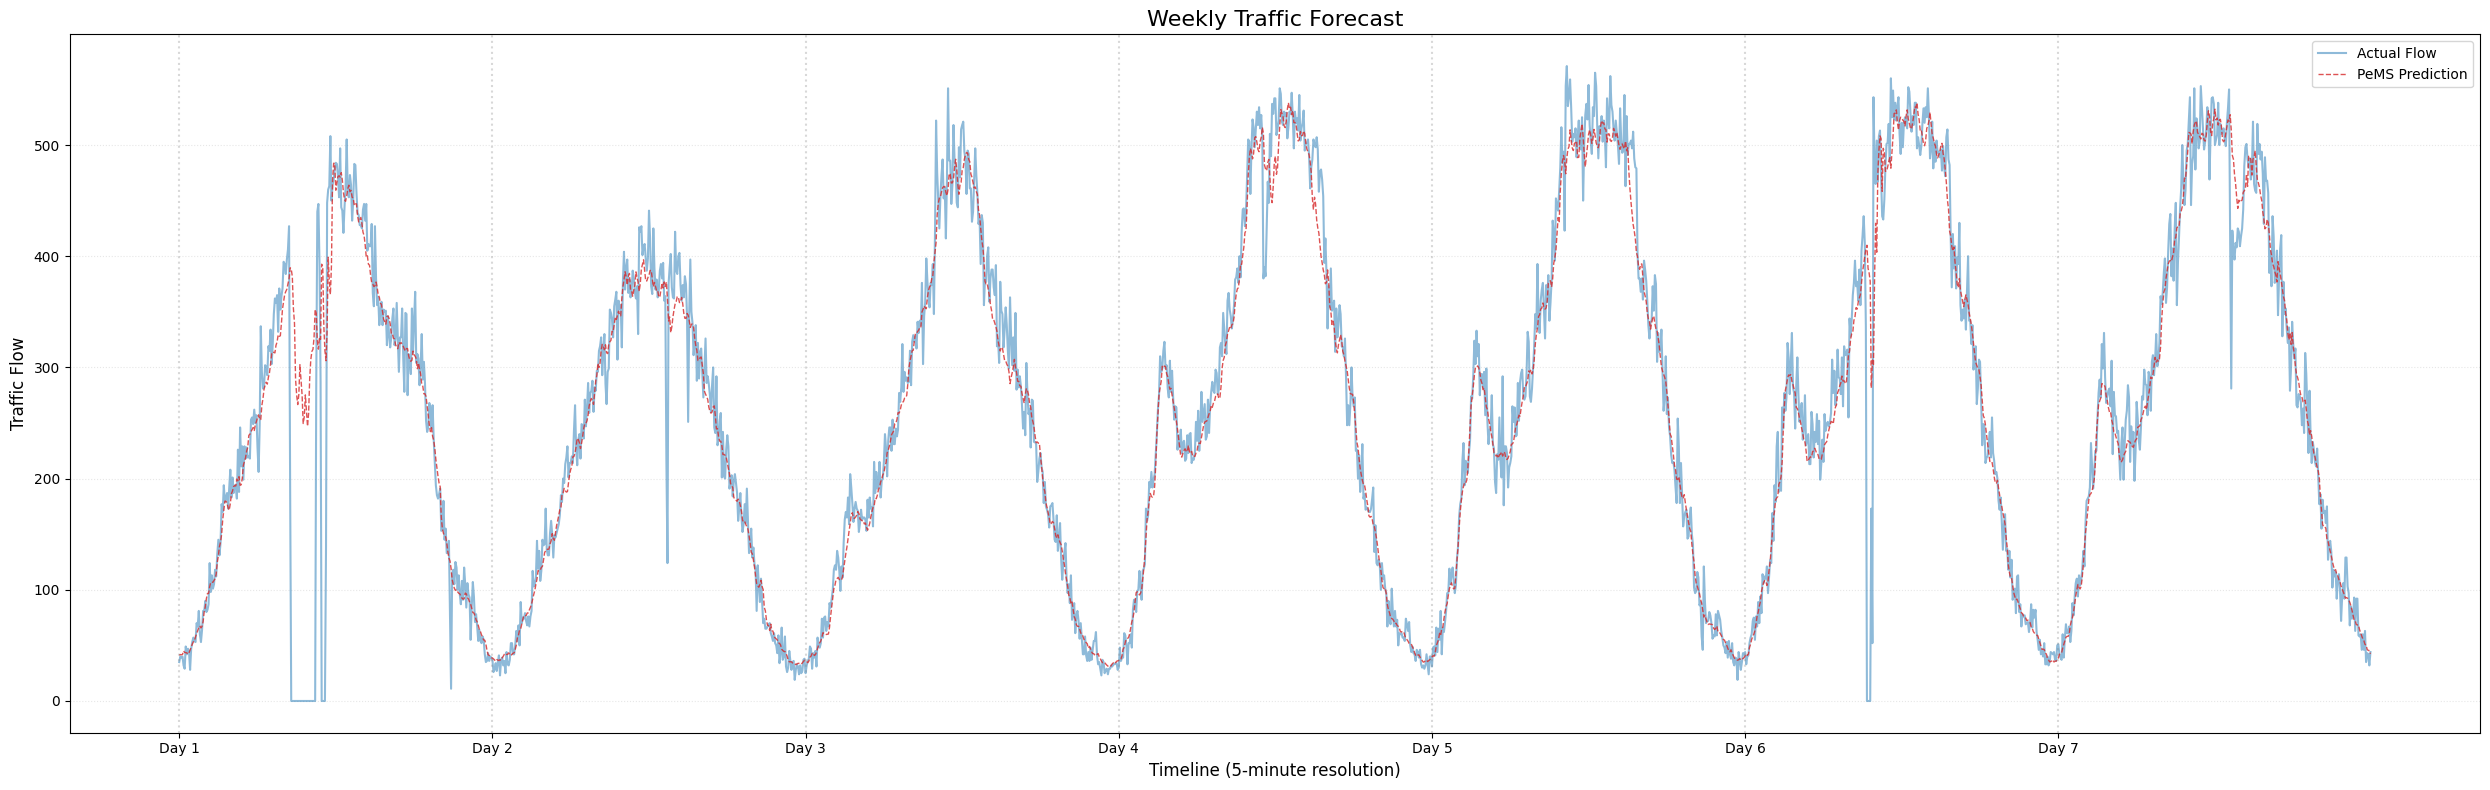


>> Collecting 1-Day PeMS data for Node 100...


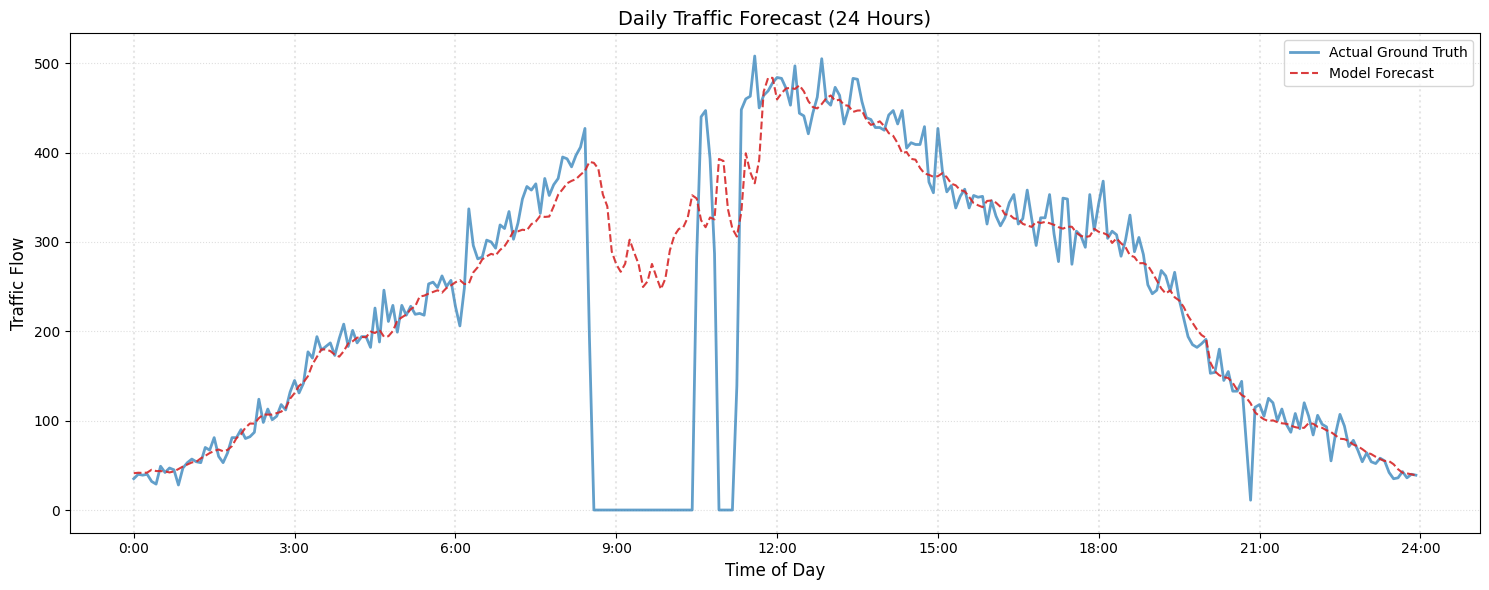

Done.


In [ ]:
import os
import time
import random
import numpy as np
import torch
from tqdm import tqdm
import shutil

class Args:
    device = "cuda" if torch.cuda.is_available() else "cpu"
    data = "taxi-pick"  
    batch_size = 8
    lrate = 1e-3
    epochs = 60
    input_dim = 3
    num_nodes = 170 
    input_len = 12
    output_len = 12
    llm_layer = 6 
    U = 2
    wdecay = 0.0001
    save = "./logs"

def main():
    args = Args()
    seed = 6666
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    

    if "taxi" in args.data: 
        args.num_nodes = 266
    elif "bike" in args.data: 
        args.num_nodes = 250
    elif "pems08" in args.data: 
        args.num_nodes = 170
    elif "pems04" in args.data: 
        args.num_nodes = 307 
    
    # FIX #2: Use local path instead of Kaggle path for local testing
    # Uncomment the appropriate line for your environment
    data_path = f"/kaggle/input/{args.data}"  # Kaggle
    
    adj_path = f"{data_path}/adj_mx.pkl"
    
    if not os.path.exists(data_path):
        print(f"Data not found at {data_path}.")
        return

    adj_data = load_graph_data(adj_path)
    
    if isinstance(adj_data, (list, tuple)):
        print(f"Detected list format from pickle. Extracting matrix...")
        adj_mx = adj_data[2] 
    else:
        adj_mx = adj_data
    
    adj_mx = np.array(adj_mx, dtype=np.float32)
    print(f"Adjacency matrix successfully loaded with shape: {adj_mx.shape}")
    
    # ========================================================================
    # FIX #3: Verify num_nodes matches adjacency matrix
    # ========================================================================
    if adj_mx.shape[0] != args.num_nodes:
        print(f"WARNING: num_nodes ({args.num_nodes}) doesn't match adj_mx ({adj_mx.shape[0]})")
        print(f"Auto-correcting num_nodes to {adj_mx.shape[0]}")
        args.num_nodes = adj_mx.shape[0]

    dataloader = load_dataset_optimized(data_path, args.batch_size, args)
    trainer = VMD_Trainer(args, dataloader["scaler"], adj_mx, args.device)

    start_epoch = 1
    best_val_loss = float('inf')
    
    # ========================================================================
    # FIX: Checkpoint and Best Model Loading from Input
    # ========================================================================
    input_ckpt_dir = f"/kaggle/input/{args.data}-checkpoint"
    input_ckpt = f"{input_ckpt_dir}/latest_checkpoint.pth"
    input_best_model = f"{input_ckpt_dir}/best_model.pth"
    local_best_model = f"{args.save}/best_model.pth"
    
    # Step 1: Try to load the existing best_model.pth from input
    if os.path.exists(input_best_model):
        print(f"Found existing best_model.pth at {input_best_model}")
        # Copy it to local logs folder so we can update it during training
        shutil.copy(input_best_model, local_best_model)
        print(f"Copied best_model.pth to {local_best_model}")
    else:
        print(f"No existing best_model.pth found at {input_best_model}")
    
    # Step 2: Load the checkpoint (model state, optimizer, epoch, best_val_loss)
    if os.path.exists(input_ckpt):
        res_epoch, res_loss = trainer.load_checkpoint(input_ckpt)
        start_epoch = res_epoch + 1
        best_val_loss = res_loss
        print(f"Resuming from Epoch {start_epoch}. Previous Best Loss: {best_val_loss:.4f}")
    else:
        print("No checkpoint found. Starting from scratch.")
        best_val_loss = float('inf')

    print("Start Training...")
    
    for epoch in range(start_epoch, args.epochs + 1):
        # ========================== TRAIN ==========================
        train_loss, t_mae, t_mape, t_rmse, t_wmape = [], [], [], [], []
        t1 = time.time()
        
        dataloader["train_loader"].shuffle()  # FIX #6: Shuffle training data each epoch

        for x, y, vmd in tqdm(dataloader["train_loader"].get_iterator(), desc=f"Epoch {epoch} Train"):
            tx = torch.Tensor(x).to(args.device).transpose(1, 3) 
            ty = torch.Tensor(y).to(args.device).transpose(1, 3)[:, 0, :, :]
            tvmd = torch.Tensor(vmd).to(args.device)
         
            l, metrics = trainer.train_step(tx, ty, tvmd)
            
            train_loss.append(l)
            t_mae.append(metrics[0])
            t_mape.append(metrics[1])
            t_rmse.append(metrics[2])
            t_wmape.append(metrics[3])
        
        # ========================== VAL ==========================
        val_loss, v_mae, v_mape, v_rmse, v_wmape = [], [], [], [], []
        
        for x, y, vmd in tqdm(dataloader["val_loader"].get_iterator(), desc=f"Epoch {epoch} Val"):
            tx = torch.Tensor(x).to(args.device).transpose(1, 3)
            ty = torch.Tensor(y).to(args.device).transpose(1, 3)[:, 0, :, :]
            tvmd = torch.Tensor(vmd).to(args.device)
            
            l, metrics = trainer.eval_step(tx, ty, tvmd)
            
            val_loss.append(l)
            # metrics is now (mae, mape, rmse, wmape) tuple, not nested lists
            v_mae.append(metrics[0])
            v_mape.append(metrics[1])
            v_rmse.append(metrics[2])
            v_wmape.append(metrics[3])
            
        # Calculate Averages
        mt_loss = np.mean(train_loss)
        mv_loss = np.mean(val_loss)
        
        print(f"\nEpoch {epoch} Results ({time.time()-t1:.1f}s):")
        print(f"TRAIN -> Loss: {mt_loss:.4f} | MAE: {np.mean(t_mae):.4f} | MAPE: {np.mean(t_mape):.4f} | RMSE: {np.mean(t_rmse):.4f}")
        print(f"VALID -> Loss: {mv_loss:.4f} | MAE: {np.mean(v_mae):.4f} | MAPE: {np.mean(v_mape):.4f} | RMSE: {np.mean(v_rmse):.4f}")
        
        # ====================================================================
        # FIX: Save best model when validation improves
        # ====================================================================
        if mv_loss < best_val_loss:
            best_val_loss = mv_loss
            torch.save(trainer.model.state_dict(), local_best_model)
            print(f">>> Saved Best Model (New Best Val Loss: {best_val_loss:.4f})")
        
        # Always save checkpoint with current best_val_loss
        trainer.save_checkpoint(epoch, best_val_loss, f"{args.save}/latest_checkpoint.pth")

    # ========================== TEST ==========================
    # Test using best model (either loaded from input or saved during training)
    if os.path.exists(local_best_model):
        test_model(trainer, dataloader, args.device, local_best_model)
    else:
        print("WARNING: No best_model.pth found! Using current model state for testing.")
        # Run test with current model (fallback)
        trainer.model.eval()
        print("\nRunning test with current model...")

    print("\n========================================")
    print("Generating Post-Training Visualizations...")
    print("========================================")
    
    if os.path.exists(local_best_model):
        trainer.model.load_state_dict(torch.load(local_best_model, weights_only=False))
    
    # ========================================================================
    # FIX #9: node_idx should be < num_nodes (170)
    # Original used 100, which is safe, but documenting this
    # ========================================================================
    viz_node = min(100, args.num_nodes - 1)
    
    visualize_model_predictions(trainer, dataloader, args, node_idx=viz_node, sample_idx=0)
    visualize_advanced_diagnostics(trainer, dataloader, args, node_idx=viz_node)
    visualize_weekly_horizon1(trainer, dataloader, args, node_idx=viz_node, num_steps=2016, start_day='Day 1')
    visualize_daily_horizon1_pems(trainer, dataloader, args, node_idx=viz_node)
    
    print("Done.")


if __name__ == "__main__":
    os.makedirs("./logs", exist_ok=True)
    main()



In [19]:
from IPython.display import FileLink
FileLink(r'logs/latest_checkpoint.pth')

/kaggle/working/logs/latest_checkpoint.pth